# WordCloud Analysis — Hotel Santika Reviews

Notebook ini memuat `dataset_absa_santika.csv` dari Google Drive dan membuat visualisasi WordCloud.

---
## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q wordcloud

import pandas as pd
import numpy as np
import re
import os
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print('Ready.')

Ready.


---
## 2. Load Dataset

In [3]:
CSV_PATH = '/content/drive/MyDrive/Scrap_Review_Santika/dataset_absa_santika.csv'

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
print(f'Dataset loaded: {len(df):,} review')
print(f'Kolom: {df.columns.tolist()}')
print(f'Rentang tanggal: {df["date"].min()} s/d {df["date"].max()}')
print()
display(df.head())

Dataset loaded: 17,868 review
Kolom: ['review_id', 'platform', 'hotel_name', 'text_review', 'date', 'original_language']
Rentang tanggal: 2010-08-02 s/d 2026-05-25



,review_id,platform,hotel_name,text_review,date,original_language
0,1,Agoda,Hotel Santika Bandung,Saya selalu menginap di Santika bila di Bandun...,2026-05-17,en
1,2,Agoda,Hotel Santika Bandung,"Bisa jalan kaki langsung ke BIP, karena lokasi...",2026-05-11,en
2,3,Agoda,Hotel Santika Bandung,Lokasinya strategis di pusat kota. Makanan saa...,2026-05-05,en
3,4,Agoda,Hotel Santika Bandung,Hotel ini agak ketinggalan jaman. Stafnya rama...,2026-03-31,en
4,5,Agoda,Hotel Santika Bandung,"Pengalaman menginap yang sangat berkesan, pros...",2026-03-26,en


In [4]:
print('--- Per Platform ---')
display(df.groupby('platform').size().to_frame('jumlah').reset_index())

print('\n--- Per Hotel ---')
display(df.groupby('hotel_name').size().to_frame('jumlah').reset_index())

if 'original_language' in df.columns:
    print('\n--- Bahasa Asli ---')
    display(df.groupby('original_language').size().to_frame('jumlah').reset_index())

--- Per Platform ---


,platform,jumlah
0,Agoda,6241
1,Tiket,2764
2,Traveloka,8863



--- Per Hotel ---


,hotel_name,jumlah
0,Hotel Santika Bandung,2783
1,Hotel Santika Bogor,4291
2,Hotel Santika Cirebon,3031
3,Hotel Santika Depok,2857
4,Hotel Santika Mega City Bekasi,2957
5,Hotel Santika Tasikmalaya,1949



--- Bahasa Asli ---


,original_language,jumlah
0,af,23
1,ar,12
2,ca,13
3,cs,6
4,cy,14
5,da,12
6,de,20
7,en,2463
8,es,4
9,et,33


---
## 3. Konfigurasi Stopwords

In [5]:
STOPWORDS_ID = {
    # --- Kata fungsi Indonesia ---
    'dan', 'di', 'yang', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'tidak', 'ada', 'juga', 'sudah', 'akan', 'bisa',
    'saya', 'kami', 'kita', 'anda', 'mereka', 'dia', 'nya',
    'sangat', 'sekali', 'lagi', 'lebih', 'saja', 'hanya', 'banyak',
    'semua', 'masih', 'kalau', 'jadi', 'karena', 'tapi', 'jika',
    'atau', 'se', 'ya', 'yg', 'tp', 'krn', 'utk', 'dg', 'dgn',
    'dr', 'dlm', 'sdh', 'udh', 'udah', 'gak', 'ga', 'gk', 'tdk',
    'sih', 'nih', 'lah', 'dong', 'deh', 'kok', 'banget', 'bgt',
    'emang', 'memang', 'cuma', 'cm', 'kalo', 'kl', 'sm', 'sama',
    'pake', 'pakai', 'buat', 'bikin', 'per', 'tiap', 'setiap',
    'belum', 'bila', 'oleh', 'hal', 'cara', 'saat', 'waktu',
    'sedang', 'telah', 'dapat', 'bagi', 'antara', 'namun',
    'seperti', 'bahwa', 'tersebut', 'agar', 'supaya', 'ketika',
    'hingga', 'sampai', 'setelah', 'sebelum', 'serta', 'maupun',
    'baik', 'makin', 'paling', 'begitu', 'maka', 'tentu',
    'harus', 'perlu', 'mau', 'ingin', 'hendak', 'boleh',
    'sering', 'jarang', 'pernah', 'cukup', 'agak', 'lumayan',
    'atas', 'bawah', 'dalam', 'luar', 'depan', 'belakang',
    'kanan', 'kiri', 'dekat', 'jauh', 'sini', 'situ', 'sana',
    'masing', 'lain', 'sesuai', 'terlalu', 'amat',
    'apa', 'siapa', 'mana', 'kapan', 'dimana', 'kemana', 'bagaimana',
    'kenapa', 'mengapa',
    # --- Singkatan & slang ---
    'sy', 'ak', 'gw', 'gue', 'lo', 'lu', 'kmu', 'km',
    'bs', 'jg', 'lg', 'org', 'trs', 'trus', 'terus',
    'bkn', 'blm', 'dpt', 'hrs', 'spy', 'ttg',
    # --- Kata fungsi Inggris ---
    'the', 'and', 'is', 'in', 'to', 'of', 'a', 'for', 'it', 'was',
    'very', 'we', 'my', 'our', 'but', 'with', 'are', 'be', 'been',
    'have', 'has', 'had', 'do', 'did', 'an', 'as', 'at', 'by', 'or',
    'so', 'if', 'no', 'not', 'this', 'that', 'can', 'all', 'will',
    'just', 'i', 'you', 'he', 'she', 'they', 'me', 'us', 'them',
    'its', 'would', 'could', 'should', 'there', 'here', 'when',
    'what', 'how', 'who', 'which', 'than', 'then', 'also', 'only',
    'more', 'really', 'still', 'about', 'some', 'much', 'even',
    'well', 'one', 'two', 'first', 'out', 'up', 'get', 'got',
    'like', 'make', 'go', 'come', 'back', 'take', 'see', 'know',
    'need', 'want', 'because', 'too', 'being', 'after', 'before',
    'over', 'were', 'am', 'on', 'from', 'each', 'where', 'own',
    # --- Kata domain hotel (noise) ---
    'hotel', 'kamar', 'santika', 'menginap', 'stay', 'room',
    'review', 'verified', 'tiket', 'com', 'agoda', 'traveloka',
    'check', 'checkin', 'checkout',
}

print(f'Stopwords: {len(STOPWORDS_ID)} kata')

Stopwords: 285 kata


---
## 4. WordCloud — Semua Review

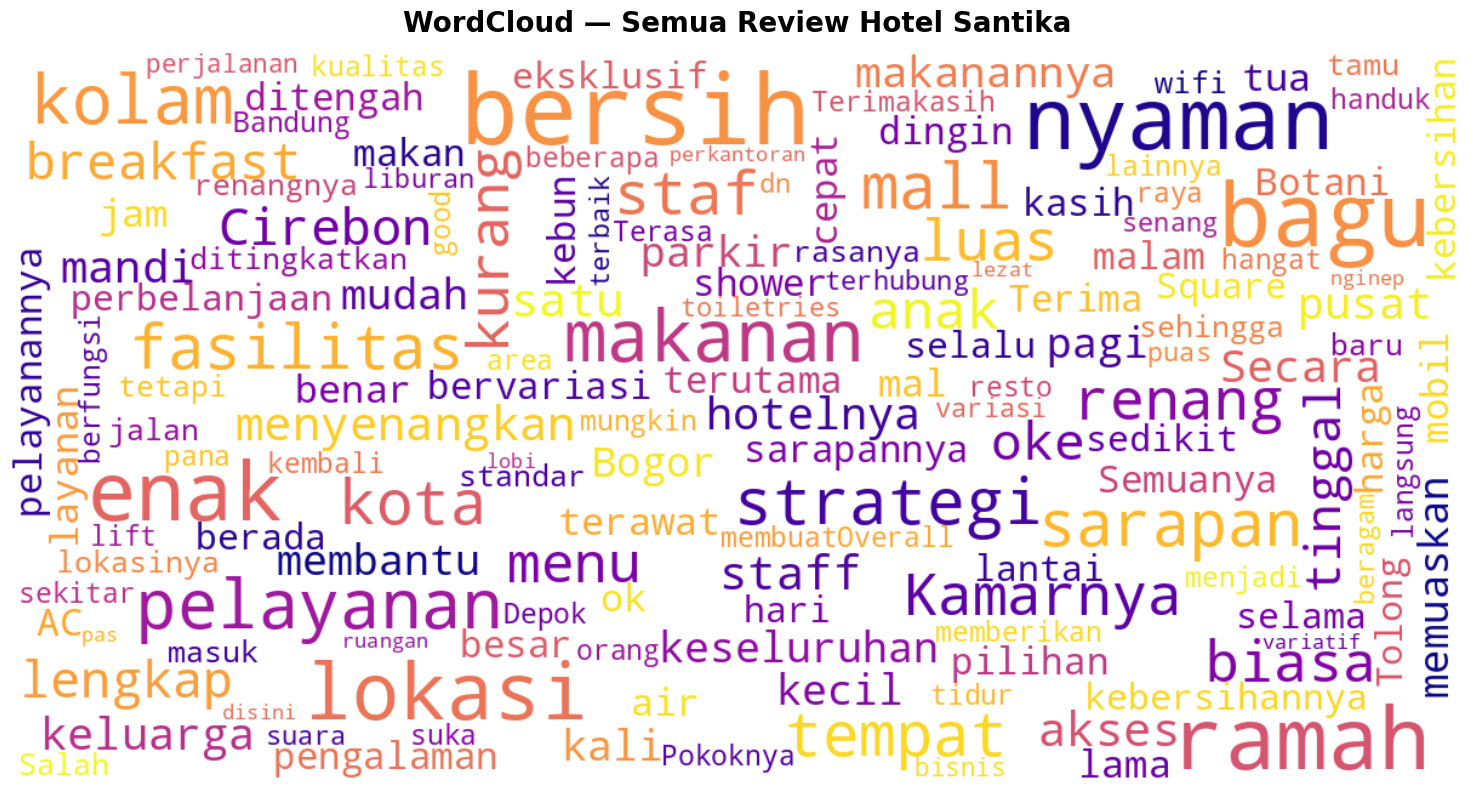

In [6]:
all_text = ' '.join(df['text_review'].dropna().astype(str).tolist())

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    stopwords=STOPWORDS_ID,
    colormap='plasma',
    max_words=150,
    min_font_size=8,
    max_font_size=80,
    collocations=False,
    random_state=42,
).generate(all_text)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation='bilinear')
ax.set_title('WordCloud — Semua Review Hotel Santika', fontsize=20, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 5. WordCloud — Per Platform

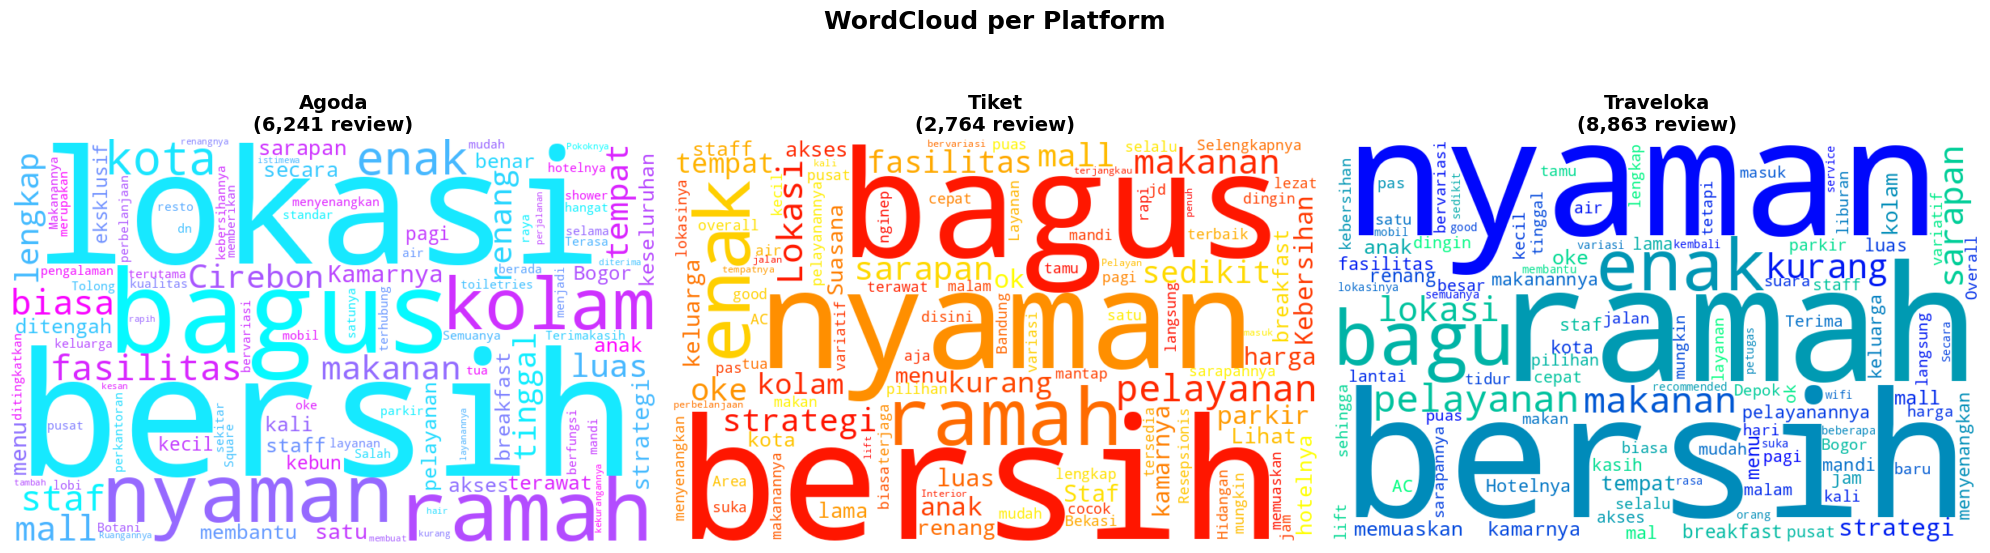

In [7]:
platforms = sorted(df['platform'].unique())
colormaps = {'Agoda': 'cool', 'Tiket': 'autumn', 'Traveloka': 'winter'}

fig, axes = plt.subplots(1, len(platforms), figsize=(20, 6))
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    text = ' '.join(df[df['platform'] == platform]['text_review'].dropna().astype(str).tolist())
    cmap = colormaps.get(platform, 'viridis')
    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        stopwords=STOPWORDS_ID,
        colormap=cmap,
        max_words=100,
        collocations=False,
        random_state=42,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    count = len(df[df['platform'] == platform])
    ax.set_title(f'{platform}\n({count:,} review)', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('WordCloud per Platform', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. WordCloud — Per Hotel

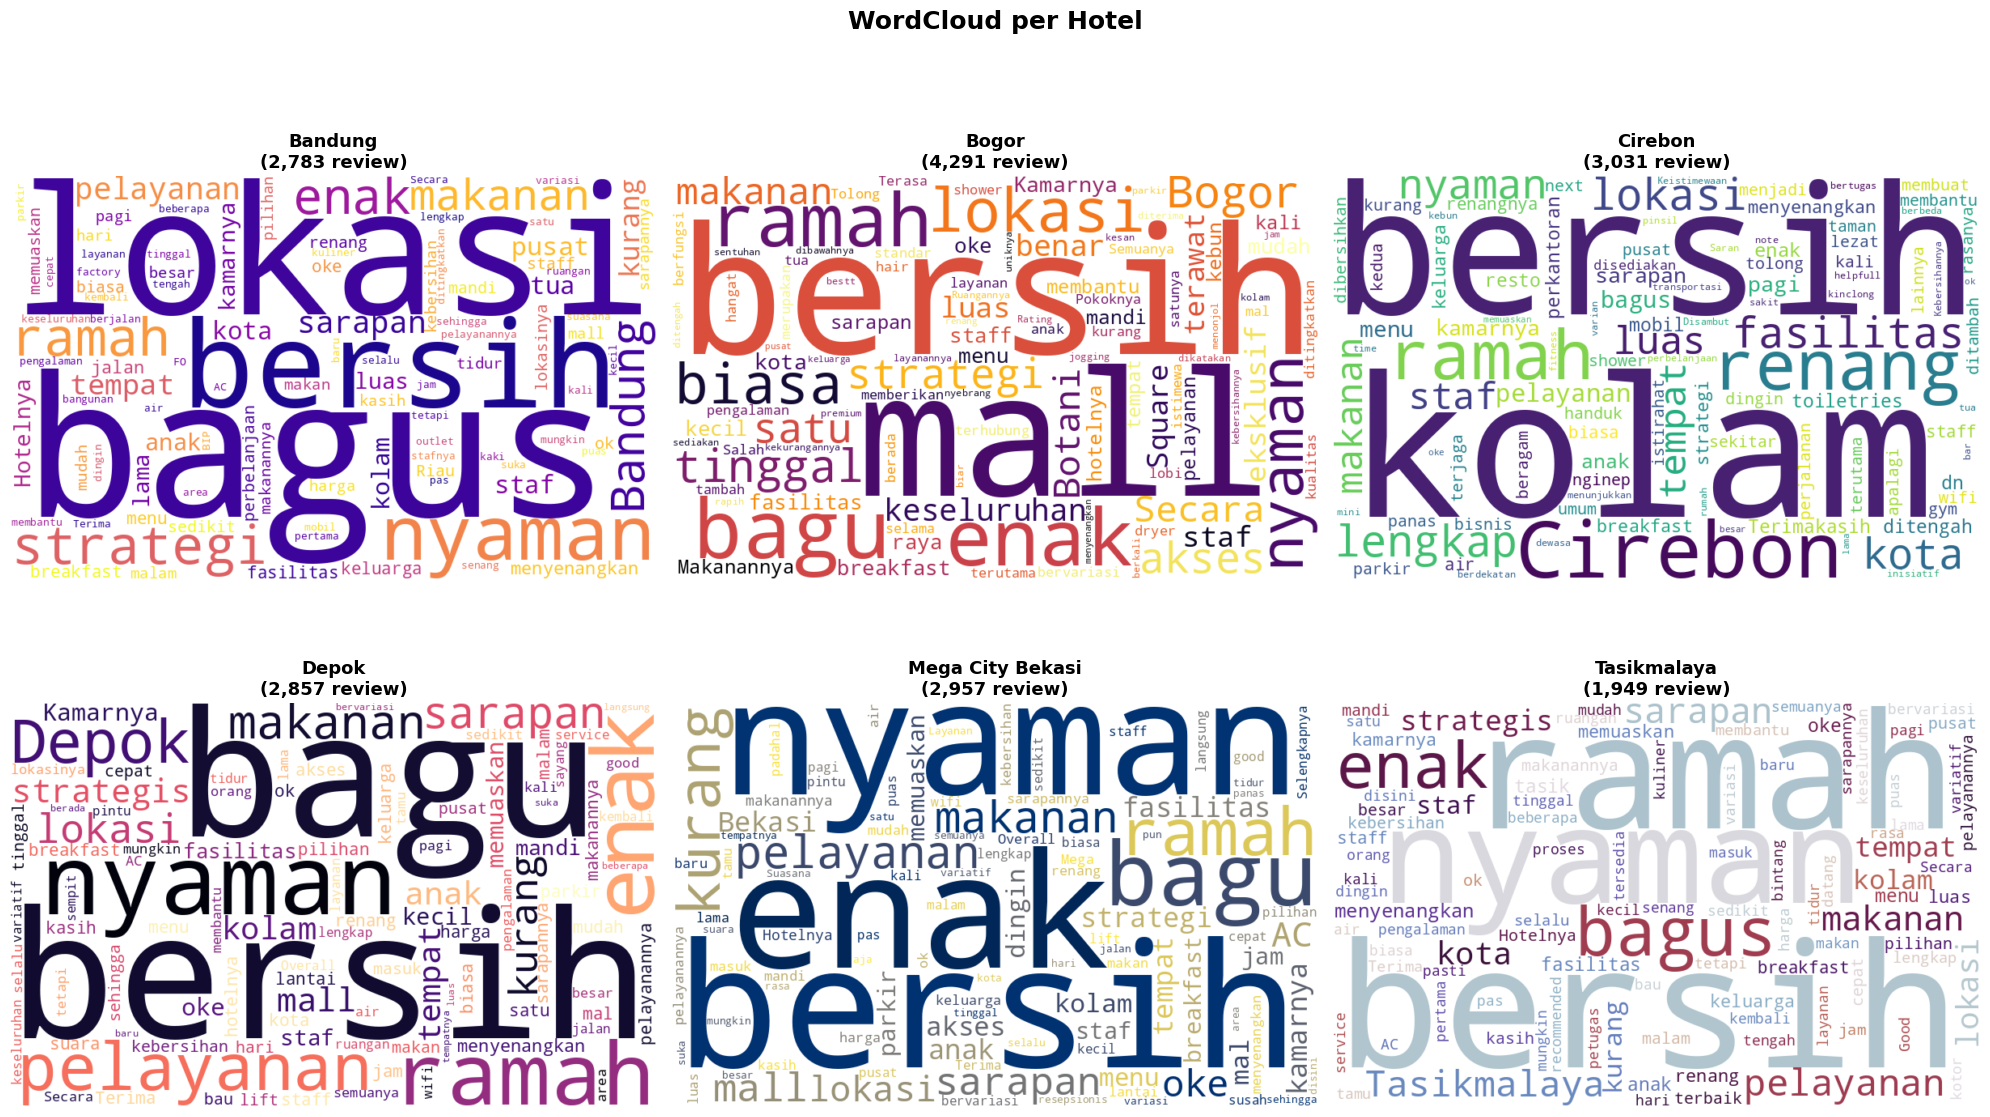

In [8]:
hotels = sorted(df['hotel_name'].unique())
n_hotels = len(hotels)
cols = 3
rows = (n_hotels + cols - 1) // cols

hotel_cmaps = ['plasma', 'inferno', 'viridis', 'magma', 'cividis', 'twilight']

fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, hotel in enumerate(hotels):
    text = ' '.join(df[df['hotel_name'] == hotel]['text_review'].dropna().astype(str).tolist())
    cmap = hotel_cmaps[i % len(hotel_cmaps)]
    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        stopwords=STOPWORDS_ID,
        colormap=cmap,
        max_words=100,
        collocations=False,
        random_state=42,
    ).generate(text)
    axes_flat[i].imshow(wc, interpolation='bilinear')
    count = len(df[df['hotel_name'] == hotel])
    short_name = hotel.replace('Hotel Santika ', '')
    axes_flat[i].set_title(f'{short_name}\n({count:,} review)', fontsize=13, fontweight='bold')
    axes_flat[i].axis('off')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('WordCloud per Hotel', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Top 20 Kata Paling Sering Muncul

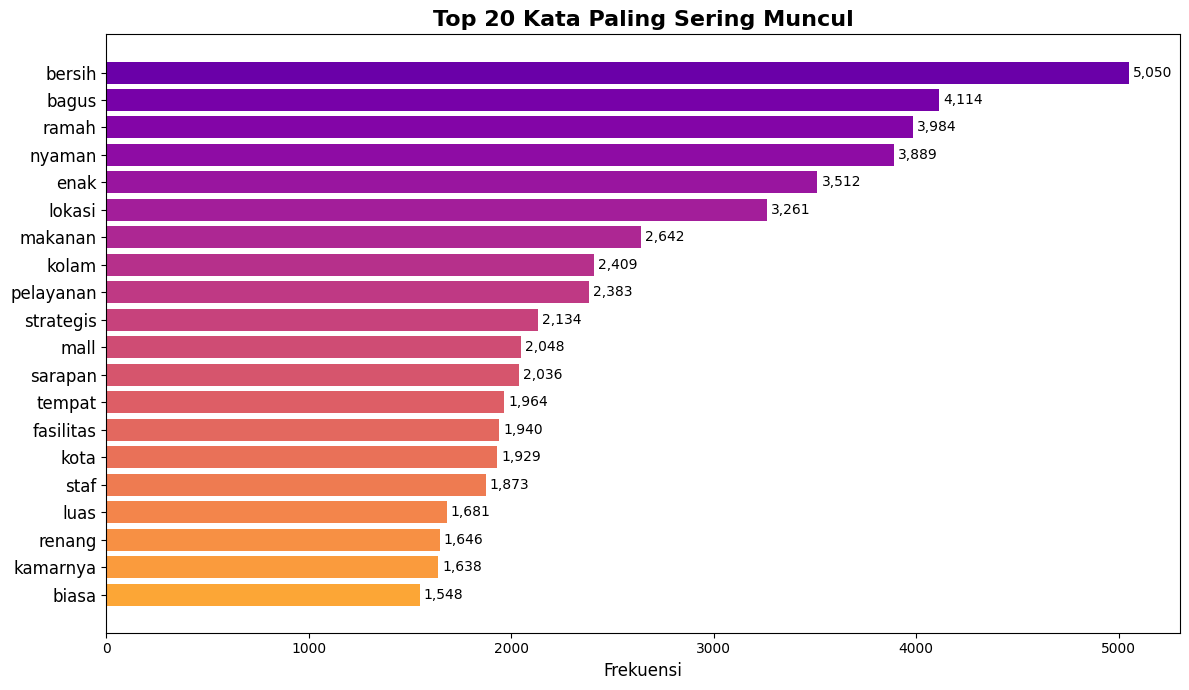


Top 20 kata:
  bersih               5,050
  bagus                4,114
  ramah                3,984
  nyaman               3,889
  enak                 3,512
  lokasi               3,261
  makanan              2,642
  kolam                2,409
  pelayanan            2,383
  strategis            2,134
  mall                 2,048
  sarapan              2,036
  tempat               1,964
  fasilitas            1,940
  kota                 1,929
  staf                 1,873
  luas                 1,681
  renang               1,646
  kamarnya             1,638
  biasa                1,548


In [9]:
all_words = []
for text in df['text_review'].dropna().astype(str):
    words = re.findall(r'[a-zA-Z\u00C0-\u024F]+', text.lower())
    words = [w for w in words if w not in STOPWORDS_ID and len(w) > 2]
    all_words.extend(words)

word_counts = Counter(all_words).most_common(20)
words, counts = zip(*word_counts)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(words)))
bars = ax.barh(range(len(words)-1, -1, -1), counts, color=colors)
ax.set_yticks(range(len(words)-1, -1, -1))
ax.set_yticklabels(words, fontsize=12)
ax.set_xlabel('Frekuensi', fontsize=12)
ax.set_title('Top 20 Kata Paling Sering Muncul', fontsize=16, fontweight='bold')

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nTop 20 kata:')
for w, c in word_counts:
    print(f'  {w:<20s} {c:,}')

---
## 8. Top 20 Kata — Per Platform

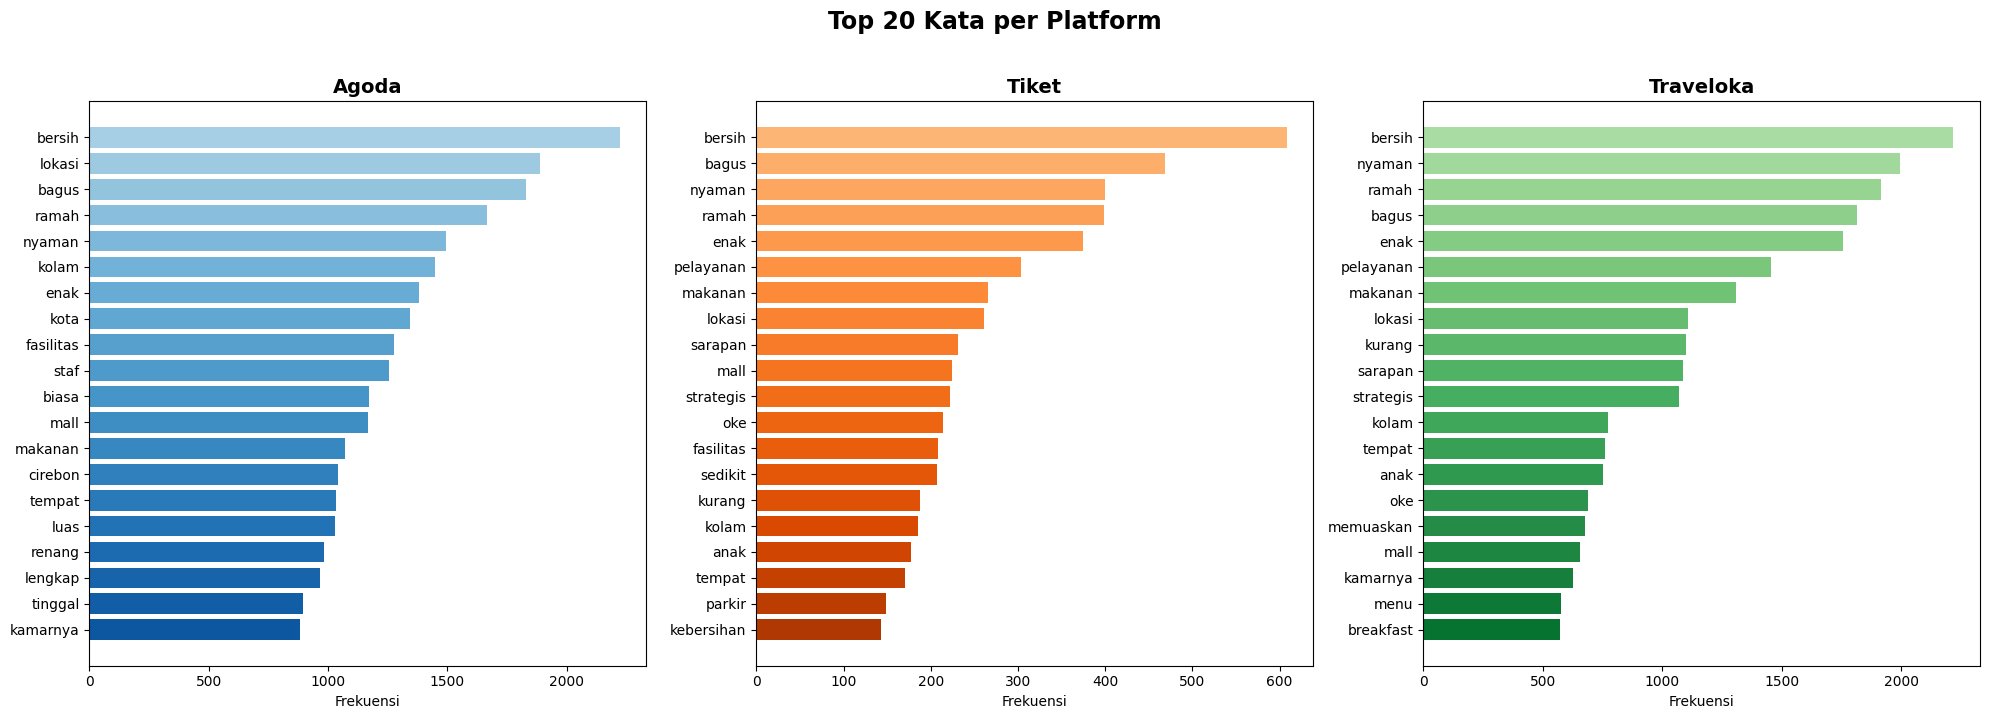

In [10]:
fig, axes = plt.subplots(1, len(platforms), figsize=(20, 7))
if len(platforms) == 1:
    axes = [axes]

platform_colors = {'Agoda': 'Blues', 'Tiket': 'Oranges', 'Traveloka': 'Greens'}

for ax, platform in zip(axes, platforms):
    plat_words = []
    for text in df[df['platform'] == platform]['text_review'].dropna().astype(str):
        tokens = re.findall(r'[a-zA-Z\u00C0-\u024F]+', text.lower())
        tokens = [w for w in tokens if w not in STOPWORDS_ID and len(w) > 2]
        plat_words.extend(tokens)

    top20 = Counter(plat_words).most_common(20)
    if not top20:
        continue
    w_list, c_list = zip(*top20)

    cmap_name = platform_colors.get(platform, 'Purples')
    colors = plt.get_cmap(cmap_name)(np.linspace(0.35, 0.85, len(w_list)))
    ax.barh(range(len(w_list)-1, -1, -1), c_list, color=colors)
    ax.set_yticks(range(len(w_list)-1, -1, -1))
    ax.set_yticklabels(w_list, fontsize=10)
    ax.set_title(f'{platform}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frekuensi')

plt.suptitle('Top 20 Kata per Platform', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()